# 4 · Complex sum: MESS reproduces phase-cycled bSSFP, bands included

A bSSFP image is the coherent sum of all orders at one echo time (Eq. 5):

$$
M_\text{bSSFP}(\Delta\omega_0,\Delta\psi)=\sum_{k=-\infty}^{\infty}S_k\Big|_{\text{TE}_0=\text{TE},\ \Delta\text{TE}=0}.
$$

Its phase increment per TR, $\theta=\Delta\omega_0\text{TR}+\Delta\psi$, varies with $\Delta\omega_0$ across the image;
where the orders cancel, a dark band appears, and changing the RF phase-cycle increment $\Delta\psi$
moves the bands. MESS measures the orders separately, so the sum can be formed after the scan,
with a **virtual phase-cycle increment** $\Delta\phi$ applied order by order (Eq. 6):

$$
M_\Sigma(\Delta\omega_0,\Delta\psi,\Delta\phi)=\sum_{k=k_1}^{k_N}S_k\,e^{ik\Delta\phi}.
$$

In the infinite-order limit both sums have the same geometric-series form (SI Eqs. S4.2, S4.3),

$$
M_\infty(\theta_\text{TE},\theta_\text{TR})=\frac{e^{\mu_++i\theta_\text{TE}}}{1-e^{\lambda_++i\theta_\text{TR}}}-\frac{e^{\mu_-+i\theta_\text{TE}}}{1-e^{\lambda_-+i\theta_\text{TR}}},
$$

with $\theta_\text{TR}=\Delta\omega_0\text{TR}+\Delta\psi$ for bSSFP and
$\theta_\text{TR}=\Delta\omega_0(\text{TR}-\Delta\text{TE})+\Delta\psi+\Delta\phi$ for the complex sum ($M_\infty$ is shorthand used here;
$\lambda_\pm,\mu_\pm$ are those of Eq. S3.3). So **$\Delta\phi$ acts exactly like $\Delta\psi$**, and the bands of $M_\Sigma$
repeat every $1/(\text{TR}-\Delta\text{TE})$ Hz instead of every $1/\text{TR}$ Hz.

One MESS acquisition ($\Delta\psi=0$) is compared with 24 bSSFP acquisitions at
$\Delta\psi=0°,15°,\dots,345°$, the phase-cycle series of the phantom experiment in the paper. The
first run simulates all 25 scans (about 20 minutes on a GPU); afterwards they load from `.cache/`.

In [1]:
import sys
import warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore", module="cupy|sigpy")

import numpy as np
import matplotlib.pyplot as plt
import mess
from mess import complex_sum, plotting, simulation as sim, theory

plotting.use_style()
CACHE = ".cache"
N_DUMMY = 2000                                    # see notebook 2

protocol = mess.MESS2D(orders=(2, -3), flip_angle=50)
bssfp = protocol.bssfp()
phantom = sim.brain_phantom(150)
cycles = np.deg2rad(np.arange(0, 360, 15))        # Δψ of the bSSFP scans = Δφ of the synthesis

S = sim.reconstruct(sim.simulate(protocol.make_sequence(phase_cycle=0.0, n_dummy=N_DUMMY),
                                 phantom, CACHE), protocol)
M_bssfp = np.stack([sim.reconstruct(sim.simulate(bssfp.make_sequence(phase_cycle=psi, n_dummy=N_DUMMY),
                                                 phantom, CACHE), bssfp)[0] for psi in cycles])
M_sigma = complex_sum(S, protocol.orders, cycles)           # Eq. 6, one image per Δφ
print("bSSFP:", M_bssfp.shape, "  complex sum:", M_sigma.shape)

bSSFP: (24, 150, 150)   complex sum: (24, 150, 150)


## Sweeping the phase cycle

Top: the bSSFP profile of one on-resonance voxel of each tissue as a function of the phase-cycle
increment (solid: Eq. 5; dashed: Eq. 6 with the six acquired orders), with the simulated values of
the bSSFP scans (●) and of the complex sum (□) marked frame by frame. Bottom: the bSSFP image at
$\Delta\psi$ and the complex sum at $\Delta\phi=\Delta\psi$, on the same grey scale. The squares on the images mark
the three voxels.

In [2]:
def on_resonance_voxel(name):
    """Interior voxel of a tissue with the smallest off-resonance."""
    from scipy.ndimage import binary_erosion
    inside = binary_erosion(phantom.mask(name), iterations=2)
    return np.unravel_index(np.argmin(np.where(inside, np.abs(phantom.off_resonance), np.inf)),
                            inside.shape)

rois = {name: on_resonance_voxel(name) for name in ("WM", "GM", "CSF")}
dense = np.linspace(0, 2 * np.pi, 361)
curves, roi_values = [], {}
for name, (ix, iy) in rois.items():
    _, t1, t2, t2p = sim.TABLE_S1[name]
    dw0 = 2 * np.pi * phantom.off_resonance[ix, iy]
    color = plotting.TISSUE_COLORS[name]
    curves.append(dict(x=dense, y=np.abs(theory.m_bssfp(protocol.te0, 50, protocol.tr, t1, t2, t2p,
                                                       dw0, dense)),
                       color=color, label=f"{name}  bSSFP, Eq. 5", direct_label=name))
    model = theory.mess_echoes(protocol.orders, protocol.te0, protocol.delta_te, 50, protocol.tr,
                               t1, t2, t2p, dw0)
    curves.append(dict(x=dense, y=np.abs(complex_sum(model, protocol.orders, dense)), color=color,
                       ls="--", lw=1.1, label=f"{name}  $M_\\Sigma$, Eq. 6"))
    roi_values[name] = (np.abs(M_bssfp[:, ix, iy]) / phantom.pd[ix, iy],
                        np.abs(M_sigma[:, ix, iy]) / phantom.pd[ix, iy])
    print(f"{name:4s} voxel {ix, iy}: off-resonance {phantom.off_resonance[ix, iy]:+.2f} Hz")

tissue = phantom.mask("WM") | phantom.mask("GM")
vmax = 2.5 * np.median(np.abs(M_bssfp[12])[tissue])   # grey scale set by WM/GM; CSF saturates
fig, anim = plotting.phase_cycle_animation(
    cycles, np.abs(M_bssfp), np.abs(M_sigma),
    left_title=lambda d: f"bSSFP  $M_\\mathrm{{bSSFP}}$,  $\\Delta\\psi$ = {d:.0f}°",
    right_title=lambda d: f"MESS complex sum  $M_\\Sigma$,  $\\Delta\\phi$ = {d:.0f}°",
    curves=curves, rois=rois, roi_values=roi_values, vmax=vmax,
    legend=("bSSFP, Eq. 5", "complex sum $M_\\Sigma$, Eq. 6", "simulated bSSFP",
            "simulated $M_\\Sigma$"),
    xlabel="RF phase cycle $\\Delta\\psi$ (bSSFP)  =  virtual phase cycle $\\Delta\\phi$ (MESS)",
    path="figures/complex_sum.gif")
plt.close(fig)

WM   voxel (np.int64(105), np.int64(115)): off-resonance +0.00 Hz
GM   voxel (np.int64(75), np.int64(29)): off-resonance +0.01 Hz
CSF  voxel (np.int64(72), np.int64(102)): off-resonance +0.37 Hz


![bSSFP phase cycling and the MESS complex sum](figures/complex_sum.gif)

The bands of both images move together as the phase cycle sweeps: the virtual phase cycle $\Delta\phi$
does what the RF phase cycle $\Delta\psi$ does, from a single acquisition. The simulated voxels follow
the profiles; the small ripples of the dashed curves are the truncation to six orders.

Four frames of the animation:

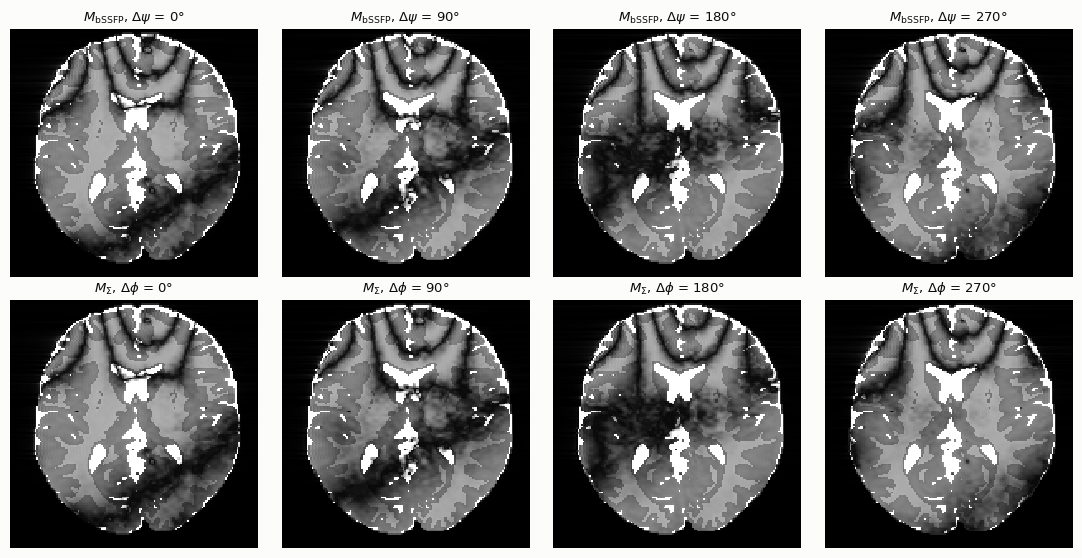

In [3]:
show = [0, 6, 12, 18]                                   # 0°, 90°, 180°, 270°
fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
for c, f in enumerate(show):
    d = np.rad2deg(cycles[f])
    plotting.show(axes[0, c], np.abs(M_bssfp[f]), vmax=vmax, title=f"$M_\\mathrm{{bSSFP}}$, $\\Delta\\psi$ = {d:.0f}°")
    plotting.show(axes[1, c], np.abs(M_sigma[f]), vmax=vmax, title=f"$M_\\Sigma$, $\\Delta\\phi$ = {d:.0f}°")
fig.tight_layout()
plt.show()

## Band spacing: $1/\text{TR}$ versus $1/(\text{TR}-\Delta\text{TE})$

Plotting every WM voxel against its off-resonance makes the difference visible. At
$\Delta\psi=\Delta\phi=\pi$ the bands of bSSFP sit at $\Delta f=(m+\tfrac12)/\text{TR}$, those of the complex sum at
$(m+\tfrac12)/(\text{TR}-\Delta\text{TE})$, because order $k$ is sampled $k\,\Delta\text{TE}$ earlier than order 0 and so
accrues $k\,\Delta\omega_0\Delta\text{TE}$ less off-resonance phase than in bSSFP.

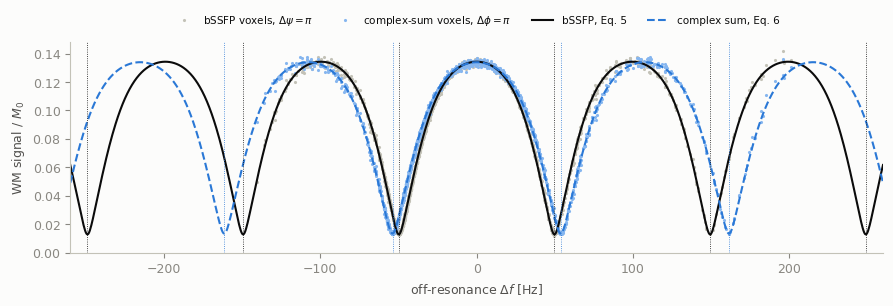

band period  bSSFP: 1/TR = 99.6 Hz,  complex sum: 1/(TR - dTE) = 107.6 Hz


In [4]:
from scipy.ndimage import binary_erosion

wm = binary_erosion(phantom.mask("WM"), iterations=1)   # leave out partial-volume edge voxels
df = phantom.off_resonance[wm]
grid_hz = np.linspace(-260, 260, 1041)
_, t1, t2, t2p = sim.TABLE_S1["WM"]
half = 12                                                # Δψ = Δφ = 180°
model_b = np.abs(theory.m_bssfp(protocol.te0, 50, protocol.tr, t1, t2, t2p, 2 * np.pi * grid_hz, np.pi))
model_s = np.abs(complex_sum(theory.mess_echoes(protocol.orders, protocol.te0, protocol.delta_te, 50,
                                                protocol.tr, t1, t2, t2p, 2 * np.pi * grid_hz),
                             protocol.orders, np.pi))
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(df, np.abs(M_bssfp[half][wm]) / phantom.pd[wm], ".", ms=2.5, color=plotting.AXIS,
        label="bSSFP voxels, $\\Delta\\psi=\\pi$")
ax.plot(df, np.abs(M_sigma[half][wm]) / phantom.pd[wm], ".", ms=2.5, color="#86b6ef",
        label="complex-sum voxels, $\\Delta\\phi=\\pi$")
ax.plot(grid_hz, model_b, color=plotting.INK, label="bSSFP, Eq. 5")
ax.plot(grid_hz, model_s, color=plotting.TISSUE_COLORS["WM"], ls="--", label="complex sum, Eq. 6")
for m in range(-3, 3):
    ax.axvline((m + 0.5) / protocol.tr, color=plotting.INK, lw=0.6, ls=":")
    ax.axvline((m + 0.5) / (protocol.tr - protocol.delta_te), color=plotting.TISSUE_COLORS["WM"],
               lw=0.6, ls=":")
ax.set_xlim(grid_hz[0], grid_hz[-1])
ax.set_ylim(bottom=0)
ax.set_xlabel("off-resonance $\\Delta f$ [Hz]")
ax.set_ylabel("WM signal / $M_0$")
ax.legend(ncol=4, fontsize=7.5, loc="upper center", bbox_to_anchor=(0.5, 1.18))
fig.tight_layout()
plt.show()
print(f"band period  bSSFP: 1/TR = {1 / protocol.tr:.1f} Hz,"
      f"  complex sum: 1/(TR - dTE) = {1 / (protocol.tr - protocol.delta_te):.1f} Hz")

## How many orders does the complex sum need?

The sum of Eq. 6 is a truncated Fourier series of the bSSFP profile (SI S1): fewer orders give a
smoother, less faithful profile. As in Fig. S4 of the paper, the same MESS data are summed over six
orders $[2,\dots,-3]$, four $[1,\dots,-2]$ and the two DESS orders $[0,-1]$. CSF, with the slowest decay of
$F_k^+$ over $k$, is the most demanding tissue.

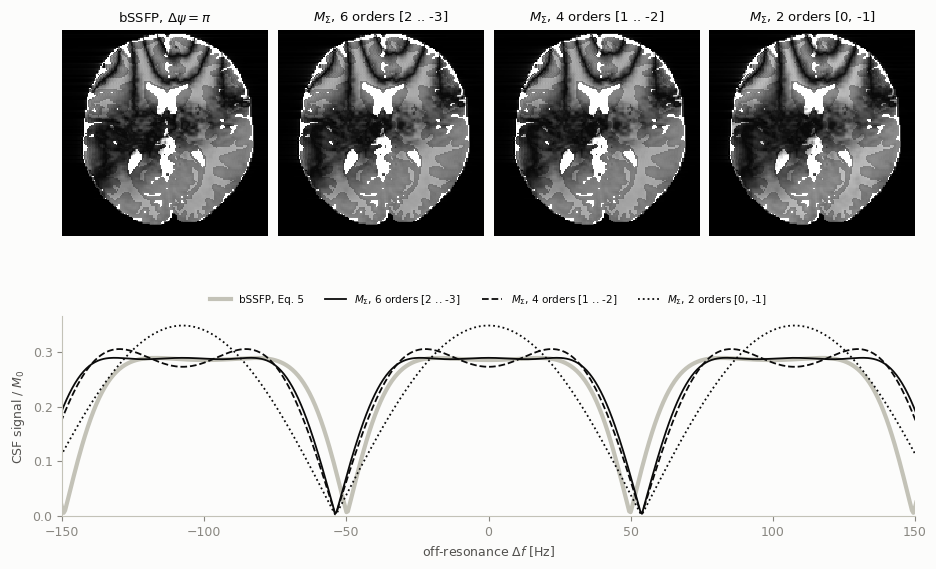

In [5]:
subsets = {"6 orders [2 .. -3]": [2, 1, 0, -1, -2, -3], "4 orders [1 .. -2]": [1, 0, -1, -2],
           "2 orders [0, -1]": [0, -1]}
index = {k: j for j, k in enumerate(protocol.orders)}
fig = plt.figure(figsize=(11, 6.4))
grid = fig.add_gridspec(2, 4, height_ratios=[1.1, 1], hspace=0.35, wspace=0.05)
plotting.show(fig.add_subplot(grid[0, 0]), np.abs(M_bssfp[half]), vmax=vmax, title="bSSFP, $\\Delta\\psi=\\pi$")
ax_p = fig.add_subplot(grid[1, :])
_, t1, t2, t2p = sim.TABLE_S1["CSF"]
full = theory.mess_echoes(np.arange(40, -41, -1), protocol.te0, protocol.delta_te, 50, protocol.tr,
                          t1, t2, t2p, 2 * np.pi * grid_hz)
ax_p.plot(grid_hz, np.abs(theory.m_bssfp(protocol.te0, 50, protocol.tr, t1, t2, t2p,
                                         2 * np.pi * grid_hz, np.pi)),
          color=plotting.AXIS, lw=3, label="bSSFP, Eq. 5")
for c, (label, ks) in enumerate(subsets.items()):
    image = complex_sum(S[[index[k] for k in ks]], ks, np.pi)
    plotting.show(fig.add_subplot(grid[0, c + 1]), np.abs(image), vmax=vmax, title=f"$M_\\Sigma$, {label}")
    model = complex_sum(full[[40 - k for k in ks]], ks, np.pi)
    ax_p.plot(grid_hz, np.abs(model), lw=1.3, color=plotting.INK, ls=["-", "--", ":"][c],
              label=f"$M_\\Sigma$, {label}")
ax_p.set_xlabel("off-resonance $\\Delta f$ [Hz]")
ax_p.set_ylabel("CSF signal / $M_0$")
ax_p.set_xlim(-150, 150)
ax_p.set_ylim(bottom=0)
ax_p.legend(ncol=4, fontsize=7.5, loc="lower center", bbox_to_anchor=(0.5, 1.0))
plt.show()

Six orders reproduce the bSSFP banding pattern closely, four smooth the bands, and the two DESS
orders keep only a sinusoidal remnant of the profile. The complex sum demonstrates the signal model:
MESS contains the complete bSSFP information, bands and all. To remove the bands, the phase of every
echo has to be discarded; that is the magnitude sum of
**[notebook 5](05_magnitude_sum.ipynb)**.